## **A Trilha da Academia**

## **Introdução**

A criopreservação, a conservação de material biológico a temperaturas muito baixas, depende do uso de crioprotetores (CPAs): substâncias químicas que evitam a cristalização e protegem as células durante o congelamento. O problema é que esses mesmos compostos são geralmente tóxicos. Em concentrações  suficientemente altas para vitrificar tecidos complexos, os CPAs danificam e matam células; e a taxa com que isso acontece depende do tipo de CPA, da concentração e do tempo de exposição.

Quantificar essa toxicidade de forma sistemática é, portanto, um problema central no design de protocolos de criopreservação. Em um artigo, Warner et al. (2022) [2] construíram um repositório com várias medições de viabilidade celular para 87 composições distintas de CPAs, cada uma avaliada em quatro tempos de exposição (5, 10, 30 e 60 minutos). Para descrever o decaimento observado, os autores adotaram um modelo cinético de primeira ordem:

$$\frac{dN}{dt} = -k \cdot N(t)$$

onde $N(t)$ é a viabilidade normalizada e $k$ é a constante de toxicidade,
inferida por regressão não-linear para cada composição. O resultado é um
conjunto de 87 pares (composição, $k$) que servem de referência para
este notebook.

O objetivo nesse notebook é, em vez de usar regressão clássica, treinar uma **Physics-Informed Neural Network (PINN)** para resolver o mesmo problema inverso, de estimar $k$ a partir dos dados de viabilidade, com a equação diferencial imposta diretamente na função de perda. 

Essa abordagem pode ser considerada adequada para este problema pelas razões de que o conjunto de dados é pequeno (quatro pontos temporais por
composição), e a lei que governa o sistema é conhecida. Nesse contexto,
a física é uma restrição que pode ser imposta, reduzindo o espaço de soluções válidas e atuando como regularizador consistente com o fenômeno.

O notebook está organizado nas seguintes secções:

- **Fundamentos**: apresenta os conceitos necessários: o que é uma rede neural, o que diferencia uma PINN de uma rede convencional, a distinção entre problema
direto e problema inverso, e a estrutura da função de perda composta
utilizada. 

- **Dados**: descreve o conjunto experimental de Warner
et al. e os pré-processamentos aplicados. 

- **``DataModule`` e Arquitetura da PINN**: detalha a arquitetura da PINN e do datamodule.

- **Otimização de hiperparâmetros**: a estratégia de otimização de hiperparâmetros com Optuna e o procedimento de inferência composição a composição.

- **Resultados e Discussão**: compara os valores de $k$ estimados pela PINN com os do artigo de referência, avaliando qual dos dois descreve melhor os dados experimentais de viabilidade.

- **Conclusão**: são a apresentadas ao conclusões finais sobre o que foi feito no notebook e o que foi obtido.

## **Fundamentos**

### **O que é uma Rede Neural?**

Uma rede neural é uma função que aprende a mapear entradas em saídas a partir de dados (exemplos) [5]. A ideia central é: empilhar transformações lineares - multiplicações por matrizes de pesos - intercaladas com funções não-lineares - as funções de ativação -, de forma que a composição resultante seja capaz de aproximar praticamente qualquer função contínua, o que é conhecido como **teorema da aproximação universal**.

Formalmente, uma rede com $L$ camadas calcula:

$$\hat{y} = f_L \circ f_{L-1} \circ \cdots \circ f_1(x)$$

onde cada $f_l(x) = \sigma(W_l x + b_l)$, sendo $W_l$ a matriz de pesos, $b_l$ o vetor de viés e $\sigma$ a função de ativação da camada $l$. A última camada é chamada de saída e a primeira camada é a camada de entrada, as camadas entre elas são as chamadas camadas ocultas.

O treinamento consiste em encontrar os valores de $W$ e $b$ que minimizam uma **função de perda**, que mede o quão erradas são as previsões $\hat{y}$ em relação aos valores reais $y$. O algoritmo usado para essa minimização é o **gradiente descendente**, que atualiza os parâmetros na direção oposta ao gradiente da perda. O gradiente é calculado pelo algoritmo de *Autograd*, que aplica a regra da cadeia ao longo do grafo computacional da rede.

Neste notebook, a rede neural implementada com *Lightning* aprende a solução da equação diferencial de morte celular — mas com uma diferença fundamental em relação a uma rede padrão: a função de perda inclui um termo que impõe a física do problema diretamente durante o treinamento.

### **O que é uma PINN?**

Uma Physics-Informed Neural Network (PINN) é uma rede neural cuja função de perda também possui o resíduo de uma equação diferencial [1]. Em vez de aprender apenas a partir de dados observados, a rede é penalizada toda vez que a saída ($\hat{y}$) viola a lei física que governa o sistema.

Em problemas científicos, frequentemente temos poucos dados experimentais mas conhecemos bem a equação que descreve o fenômeno. Ao ignorar essa informação e treinar uma rede apenas com os dados observados, parte do conhecimento disponível é descartado, o que frequentemente resulta em overfitting.

As PINNs permitem que a equação diferencial atue como um regularizador consistente com a física do problema.

### **A equação cinética de viabilidade celular**

O modelo adotado por Warner et al. (2022) [2] descreve a morte celular por crioprotetores como um processo de primeira ordem:

$$\frac{dN}{dt} = -k \cdot N(t)$$

onde $N(t) \in [0, 1]$ é a viabilidade celular normalizada no instante $t$ (em minutos) e $k > 0$ é a constante cinética de morte, que depende da composição da solução crioprotetora.

A solução analítica dessa EDO com condição inicial $N(0) = 1$ é simplesmente:

$$N(t) = e^{-kt}$$

O que torna esse problema mais interessante é que $k$ não é observado diretamente. Ele precisa ser inferido a partir de medições de viabilidade em apenas quatro instantes de tempo (5, 10, 30 e 60 minutos). Esse é um **problema inverso**: em vez de usar $k$ para prever $N(t)$, queremos usar $N(t)$ para descobrir $k$.

#### **O problema direto e o problema inverso**

É válido distinguir essas duas formas de utilizar uma PINN, pois exigem diferentes implementações.

- **problema direto**: $k$ é conhecido e queremos que a rede aprenda a função $N(t)$ que satisfaz a EDO. Os parâmetros treináveis são apenas os pesos e vieses da rede neural.

- **problema inverso** (que é o nosso caso): $k$ é desconhecido e queremos descobri-lo a partir dos dados. Para isso, $k$ é tratado como um "*parâmetro treinável adicional*", inicializado com um valor inicial e atualizado pelo otimizador que atualiza os pesos da rede.

### **A função de perda composta**

A função de perda de uma PINN pode ter três termos, cada um com um papel distinto [3]:

$$L = \cdot L_\text{dados} + \cdot L_\text{física} + L_\text{ci}$$

- **Perda de dados** ($L_\text{dados}$): mede o quão bem a rede capta as viabilidades observadas nos tempos experimentais. Pode ser, por exemplo, calculada pela raiz quadrada do erro médio (MSE) entre $N_\text{previsto}(t_i)$ e $N_\text{observado}(t_i)$, ou outras métricas como o erro médio absoluto (MAE) e a perda de Huber.

- **Perda física** ($L_\text{física}$): mede o quanto a saída da rede viola a EDO ($dN/dt + kN = 0$). Esse resíduo é avaliado em pontos amostrados aleatoriamente no intervalo $[0, t_{\text{max}}]$ (no nosso caso foi utilizado o tempo normalizado), que não necessariamente coincidem com os tempos experimentais.

- **Perda da condição inicial** ($L_\text{ci}$): Faz com que a rede respeite a condição inicial ($N(0) = 1$). Sem esse termo, nada impede que a rede aprenda uma curva deslocada que satisfaz a EDO, mas que não condiz com a condição física do problema.

<!-- e foram otimizados pelo Optuna junto com os demais hiperparâmetros. -->

## **Importação das bibliotecas**

In [ ]:
import os
import csv

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from optuna import create_study
from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend, JournalFileOpenLock

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

import lightning as L

plt.rcParams.update({"font.family": "serif", "mathtext.fontset": "cm", "font.size": 12})

## **Dataset e pré-processamento**

Os dados utilizados neste notebook foram extraídos do material suplementar de Warner et al. (2022) [2] (brutos: ``Single-and-Binary-Data-Report.csv`` e ``Ternary-Data-Report.csv``), que reportam medições de viabilidade celular para células endoteliais bovinas expostas a soluções de crioprotetores. O conjunto abrange 87 composições distintas, simples, binárias e ternárias, dos cinco CPAs estudados (glicerol, DMSO, propilenoglicol, etilenoglicol e formamida), cada uma avaliada em quatro tempos de exposição: 5, 10, 30 e 60 minutos, com 5 a 6 réplicas
por condição. 

Após a extração, os dados foram organizados em dois arquivos CSV separados (`dados_simples_e_binarios.csv` e `dados_ternarios.csv`), juntados logo no início do pipeline.

### **Anomalias observadas nos dados brutos**

Antes de descrever o pré-processamento, é necessário explicar duas anomalias
que aparecem nos dados brutos. 

A primeira é a presença de **viabilidades maiores que 1,0**. A viabilidade reportada no artigo é calculada como uma razão de fluorescências normalizada pelo controle positivo:

$$\text{viabilidade} = \frac{F_f \cdot F_i^P}{F_i \cdot F_f^P}$$

onde: 

- $F_f$: é a fluorescência final da amostra.
- $F_i$: é a fluorescência inicial da amostra.
- $F_i ^P$: é a fluorescência inicial do fontrole positivo (condições ideais).
- $F_f ^P$: é a fluorescência final do fontrole positivo (condições ideais).

Como há variabilidade biológica natural, algumas células podem crescer ligeiramente mais rápido que o controle durante o período de experimentação, resultando numa razão acima de 1,0, o que não representa, realmente, um aumento real de viabilidade, está mais para um ruído do experimento e modelo de normalização adotado.

A segunda anomalia é a ocorrência de **viabilidade crescente ao longo do tempo** em alguns casos (por exemplo, $N(5\text{min}) = 0{,}84 \rightarrow N(10\text{min}) = 0{,}93$), o que contradiz o comportamento de decaimento assumido pela EDO. Para isso, considerou-se a possibilidade de ocorrido um erro na medição da amostra de forma que em determinada região poderia haver uma maior concentração de CPA, e a fluorescência foi medida de forma heterogênea na amostra.

### **Etapas de pré-processamento**

O código abaixo executa três etapas:

1. **Filtro de outliers extremos:** registros com viabilidade fora do intervalo $[-0{,}002,\; 1{,}1]$ são removidos. O limite inferior ligeiramente negativo tolera resquícios de fluorescência; o limite superior de 1,1 remove medições em que houve um grande desvio.

2. **Clip para $[0, 1]$:** após o filtro, valores residuais fora do intervalo físico são "encaixados" nos valores de $0{.}0$ a $1{,}0$. Garantindo que não haja valores fora do domínio esperado.

3. **Agrupamento por (composição, tempo):** as réplicas de cada condição são consolidadas em um único valor representativo. O código atual usa a média, que é uma escolha razoável, mas sensível a outliers. Uma alternativa mais robusta (só foi percebido depois) seria utilizar a mediana.

In [86]:
df_simp_bin = pd.read_csv("dados/dados_simples_e_binarios.csv")
df_ter = pd.read_csv("dados/dados_ternarios.csv")

df_completo = pd.concat([df_simp_bin, df_ter], ignore_index=True)

df_completo = df_completo[~((df_completo["Cell Viab (%)"] < -0.002) | (df_completo["Cell Viab (%)"] > 1.1))]
df_completo["Cell Viab (%)"] = df_completo["Cell Viab (%)"].clip(lower=0, upper=1.0)

cpas = ["Gly (mol/L)", "DMSO (mol/L)", "PG (mol/L)", "EG (mol/L)", "FA (mol/L)"]

df_tratado = df_completo.groupby(cpas + ["Exp Time (min)"])["Cell Viab (%)"].mean().reset_index()

print(f"df tratado {df_tratado.shape}:")
display(df_tratado.tail())

df tratado (344, 7):


,Gly (mol/L),DMSO (mol/L),PG (mol/L),EG (mol/L),FA (mol/L),Exp Time (min),Cell Viab (%)
339,7.0,0.0,0.0,0.0,0.0,60,0.179575
340,10.0,0.0,0.0,0.0,0.0,5,0.950004
341,10.0,0.0,0.0,0.0,0.0,10,0.863450
342,10.0,0.0,0.0,0.0,0.0,30,0.476486
343,10.0,0.0,0.0,0.0,0.0,60,0.005168


O resultado é o `df_tratado`, com 344 linhas, cada uma correspondendo a um par único (composição, tempo) com sua viabilidade.

## **``DataModule``** [6, 7]

Antes de construir a PINN, é preciso organizar como os dados chegam até ela durante o treinamento. Para isso, foi utilizado o ``L.LightningDataModule``, uma classe do Lightning que centraliza a lógica de preparação e carregamento dos dados em um lugar. Isso facilita orquestrar as etapas de treino, validação e teste.

Duas configurações importantes do ``DataModule`` são: 

- **``tamanho_lote``**: representa o número de exemplos que serão utilizados para treinar o modelo ao mesmo tempo. De forma que se tivermos um conjunto de dados com 1000 exemplos e um tamanho de lote de 100, o modelo será atualizado 10 vezes por época, ou seja, a cada 100 exemplos. Se o tamanho do lote for muito pequeno, o modelo pode demorar mais para convergir, visto que os pesos são atualizados com mais frequência, o que pode também levar a um aprendizado mais ruidoso.


    Foi utilizado o ``train_dataloader`` com ``batch_size=32``, mesmo tendo apenas 4 pontos de treino. Esse valor maior que o necessário funciona como um teto que foi mantido para consistência com o pipeline de otimização, que testará o mesmo ``batch_size`` em uma outra composição que pode ter mais pontos.

- **``num_trabalhadores``**: representa quantos núcleos de processamento (CPU) você deseja utilizar para as operações relacionadas aos dados. É importante não escolher um valor muito pequeno, para que não haja um garagalo no treinamento, mas também não é recomendado escolher um valor muito alto, para evitar sobrecarregar o sistema e afetar outras tarefas.

### **O que entra como treino e o que entra como validação** 

Aqui foi feita uma escolha que pode parecer "estranha" e é válido explicá-la.

O **``conjunto de treino``** é composto pelos pontos experimentais: os quatro pares $(t_i, N_i)$ medidos a 5, 10, 30 e 60 minutos. São esses pontos que a rede precisa aprender o padrão.

O **``conjunto de validação``** é composto por um único ponto: $N(0) = 1$. Apenas.

A razão para fazer a validação apenas na condição inicial é que há quatro pontos de treino, e não são dados suficientes para reservar uma parte como validação. O que existe é uma restrição física de que, no instante zero, antes de qualquer exposição ao crioprotetor, a viabilidade celular é 1. 

In [87]:
class DataModule(L.LightningDataModule):
    def __init__(
        self,
        tempos_reais,
        viabilidade_real,
        tempos_teste=None,
        viabilidade_teste=None, 
        tamanho_lote=32,
        num_trabalhadores=2,
    ):
        super().__init__()
        self.tempos_reais = tempos_reais
        self.viabilidade_real = viabilidade_real
        self.tempos_teste = tempos_teste
        self.viabilidade_teste = viabilidade_teste
        self.tamanho_lote = tamanho_lote
        self.num_trabalhadores = num_trabalhadores

    def setup(self, stage=None):
        t_train = torch.tensor(self.tempos_reais, dtype=torch.float32).view(-1, 1)
        N_train = torch.tensor(self.viabilidade_real, dtype=torch.float32).view(-1, 1)
        
        if stage == "fit" or stage is None:
            self.dataset_treino = TensorDataset(t_train, N_train)
            
            t_val = torch.tensor([[0.0]], dtype=torch.float32)
            N_val = torch.tensor([[1.0]], dtype=torch.float32)
            self.dataset_val = TensorDataset(t_val, N_val)

        if stage == "test" or stage is None:
            if self.tempos_teste is not None and self.viabilidade_teste is not None:
                t_test = torch.tensor(self.tempos_teste, dtype=torch.float32).view(-1, 1)
                N_test = torch.tensor(self.viabilidade_teste, dtype=torch.float32).view(-1, 1)
                self.dataset_teste = TensorDataset(t_test, N_test)
            else:
                self.dataset_teste = None

    def train_dataloader(self):
        return DataLoader(
            self.dataset_treino, 
            batch_size=self.tamanho_lote,
            num_workers=self.num_trabalhadores,
            persistent_workers=True,
            shuffle=True
        )

    def val_dataloader(self):
        return DataLoader(
            self.dataset_val, 
            batch_size=1,
            num_workers=self.num_trabalhadores,
            persistent_workers=True,
            shuffle=False,
        )

    def test_dataloader(self):
        if self.dataset_teste:
            return DataLoader(
                self.dataset_teste, 
                batch_size=self.tamanho_lote,
                num_workers=self.num_trabalhadores,
                persistent_workers=True,
                shuffle=False,
            )
        return None

## **Arquitetura da PINN**

Para criar a PINN utiliza-se a mesma base do ``L.LightningModule`` e reúne três responsabilidades: a arquitetura da rede neural, o cálculo da função de perda (dados + física + condição inicial) e a configuração do otimizador.

### **Construção da Arquitetura** [6, 7]

A rede recebe o tempo normalizado $\tilde{t} \in [0, 1]$ como única entrada e produz a viabilidade prevista $\hat{N}(\tilde{t})$ como saída. A arquitetura é construída a partir da lista `camadas_ocultas`, o que permite ao Optuna variar o número de camadas e o tamanho de cada uma entre os trials.

A camada de saída não possui uma função de ativação, porque ao manter a saída da rede linear, sem uma função de ativação, há um caminho direto para que o cálculo da derivada ($dN/dt$) informe ao otimizador como ajustar o modelo.

Se fosse utilizada uma função de ativação, como a Sigmoid, ao final, o cálculo da derivada

$$\frac{d\hat{N}}{dt} = \sigma'(z) \cdot \frac{dz}{dt}$$

introduziria um "filtro" matemático que poderia desvanecer o sinal do gradiente (a derivada iria se aproximar de 0) conforme a viabilidade se aproximasse de 0 ou 1, a região de saturação da função. Isso dificultaria o entendimento da rede sobre: "*Se eu mudar o tempo $t$ um pouco, quanto a sua previsão de viabilidade $N(t)$ muda?*".

### **O parâmetro k**

Além dos pesos e vieses da camada, o modelo tem um parâmetro ``self.log_k``, que representa o logaritmo da constante cinética que se busca descobrir, definido como ``nn.Parameter``.

Essa declaração faz com que essa variável seja tratada como qualquer outro parâmetro treinável, recebendo um gradiente durante o *backpropagation* e sendo atualizado pelo otimizador a cada passo.

> **Por que o log?** A parametrização pelo `log_k` em vez de `k` diretamente é uma escolha que visa colocar a busca em escala logarítmica, tendo em vista as variações em ordens de grandeza do parâmetro entre as diferentes composições (de $k \approx 10^{-4}$ para soluções pouco tóxicas até $k \approx 10$ para as mais tóxicas). Assim, com a busca na escala logarítmica o otimizador consegue variar mais facilmente os valores de $k$, evitando ficar preso em mínimos locais.



### **O ``training_step``**

> **``NOTA``**: *No âmbito desse projeto, a definição da função de perda, o número de pontos físicos e os pesos para as perdas como parâmetros para o Optuna é algo um tanto quanto questionável e deve ser preferêncialmente removido nas próximas atividades que envolvem o projeto.*

O ``training_step`` é chamado a cada batch e é onde a função de perda é calculada. Essa etapa pode ser dividida em quadro partes:

1. **Normalizar o tempo dos dados:** 

    O tempo experimental (5, 10, 30, 60 minutos) é normalizado para $[0, 1]$ dividindo por ``t_max = 60``, antes de ser passado para rede. Isso foi feito para manter os gradientes em uma escala razoável, pois se o tempo não estivesse normalizado, o valor da derivada $dN/dt$ seria bem menor em magnitude do que os valores de viabilidade, fazendo com que a rede "subestimasse" a física.

2. **Perda dos dados experimentais:**

    Com os tempos (normalizados) recebidos a rede prevê os valores de viabilidade, que são comparados com as viabilidades observadas. Por se tratar de dados experimentais e de se esperar qua haja outliers, e para entender se é mais adequado que a rede considere ou desconsidere os pontos fora da curva, conforme a natureza dos dados, a função de perda foi colocada como um parâmetro para o Optuna (MSE, MAE e Huber).

    > **OBS**: As funções de perda utilizadas estão detalhadas no apêndice do notebook

3. **Perda física:**

    Essa é a parte que transforma a rede em uma PINN. Primeiro são amostrados ``num_pontos_fisica`` pontos aleatórios no intervalo $[0, 1]$ (o do tempo normalizado). Eles não precisam coincidir com os tempos experimentais, a ideia é cobrir densamente o domínio para que a EDO seja respeitada em toda a trajetória.

    ```python
    t_fisica = torch.rand(self.num_pontos_fisica, 1).to(self.device)
    t_fisica.requires_grad = True
    ```

    Foi utilizado o ``requires_grad=True`` para dizer ao PyTorch manter o grafo do tensor, o que vai permitir calcular a derivada da saída da rede em relação a ``t_fisica`` no passo seguinte.

    Em seguida, a rede faz uma previsão nesses pontos e o autograd calcula $dN/d\tilde{t}$ pela regra da cadeia aplicada ao grafo da rede (não é por diferenças finitas).

    Como para atualizar os pesos e parâmetros da rede é necessário calcular o gradiente da perda em relação aos mesmos, e como a função de perda da PINN contém uma derivada, os argumentos ``create_graph=True`` e ``retain_graph=True`` garantem que haverá um grafo para que os gradientes (as derivadas segunda) possam ser calculados.

    O resíduo da EDO pode ser calculado pelo erro quadrático médio:
    
    ```python
    residuo = dN_dt + (self.k * self.t_max * N_previsto_fisica)
    perda_fisica = torch.mean(residuo ** 2)
    ```

    > A variável ``self.t_max`` aparece porque estamos trabalhando em um tempo normalizado. A EDO original é $dN/dt = -kN$, mas em termos de $\tilde{t} = t/t_\text{max}$, aplicando a regra da cadeia, ela se torna $dN/d\tilde{t} = -k \cdot t_\text{max} \cdot N$, e o resíduo precisa refretir essa parte matemática. Se a rede satisfaz perfeitamente a equação, o resíduo é zero em todo o domínio e a perda física é nula.

    4. **Perda da condição inicial:**

    Por fim, a rede é avaliada em $\tilde{t} = 0$ e penalizada se não prever $N = 1$.

    Esse termo existe para que a rede, além de respeitar a forma da EDO também respeite o ponto de partida dela. Sem esse termo a rede poderia aprender toda a função exponencial, mas começar em $N(0) = 0.8$.

    5. **Perda total:**

    Os três termos são combinados com um ajuste de pesos:

    ```python
    perda_total = (self.peso_dados * perda_dados) + (self.peso_fisica * perda_fisica) + perda_cond_ini
     ```

    Os pesos ``peso_dados`` e ``peso_fisica`` controlam o balanço entre o quanto considerar as perdas físicas e dos dados experimentais.

    > **OBS**: a perda da condição inicial sempre tem peso 1, apenas ``peso_dados`` e ``peso_física`` são hiperparâmetros do Optuna. A ideia por trás dessa escolha é de não permitir que, por algum motivo, a condição inicial, uma restriçaõ rígida, seja atenuada pelo otimizador.



### **O ``validation_step``**

Na validação, a rede recebe $\tilde{t} = 0$ e a perda é o quadrado do erro em relação a $N = 1$.

### **O otimizador**

Para atualizar os pesos da rede e minimizar o erro durante o treinamento, foi utilizado o otimizador **Adam** (*Adaptive Moment Estimation*). Esse otimizador ajusta individualmente as taxas de aprendizado para cada parâmetro, em que a quantidade ajustada é influenciada por ambos: o primeiro momento (capturando a quantidade de movimento dos gradientes) e o segundo momento (refletindo a variabilidade dos gradientes). Isso permite que o Adam se adapte dinamicamente ao longo do treinamento, com uma taxa de aprendizado adaptativa, baseada no quão frequente um parâmetro é atualizado [10].

Nos pesos e vieses da rede foi aplicada a regularização pelo **``weight_decay``**, ela adiciona uma pequena penalidade à função de perda baseada no tamanho dos parâmetros: quanto maiores os pesos, maior a penalidade.

> A razão para que o ``self.log_k`` tenha um ``weight_decay=0.0`` é porque o weight decay conduz os parâmetros a zero, isso forçaria $k$ a ser menor do que o seu valor real.

> A parte mais matemática do *weight decay* e do otimizador Adam está descrita no apêndicie.

In [88]:
class PINN(L.LightningModule):
    def __init__(
        self, 
        num_dados_entrada,
        camadas_ocultas,
        funcao_ativacao,
        num_targets,
        fun_perda_dados,
        t_max=60,
        peso_dados=1.0,
        peso_fisica=1.0,
        num_pontos_fisica=1000,
        learning_rate=1e-3,
        k_inicial=0.01 # é um chute 
    ):
        super().__init__()

        self.save_hyperparameters() 
        self.log_k = nn.Parameter(torch.log(torch.tensor(k_inicial, dtype=torch.float32)))  
        self.learning_rate = learning_rate
        self.num_pontos_fisica = num_pontos_fisica
        self.fun_perda_dados = fun_perda_dados
        self.peso_dados = peso_dados
        self.peso_fisica = peso_fisica
        self.t_max = t_max

        arquitetura = []

        # primeira camada oculta
        arquitetura.append(nn.Linear(num_dados_entrada, camadas_ocultas[0]))
        arquitetura.append(funcao_ativacao)

        # demais camadas ocultas
        for i in range(1, len(camadas_ocultas)):
            arquitetura.append(nn.Linear(camadas_ocultas[i - 1], camadas_ocultas[i]))
            arquitetura.append(funcao_ativacao)

        # camada de saída
        arquitetura.append(nn.Linear(camadas_ocultas[-1], num_targets))

        self.camadas = nn.Sequential(*arquitetura)

    def forward(self, t):
        N_previsto = self.camadas(t)
        return N_previsto
    
    def training_step(self, batch, batch_idx):
        t_dados, N_dados = batch
        
        t_dados_norm = t_dados / self.t_max 

        t_fisica = (torch.rand(self.num_pontos_fisica, 1)).to(self.device)
        t_fisica.requires_grad = True 

        N_previsto_dados = self(t_dados_norm)
        perda_dados = self.fun_perda_dados(N_previsto_dados, N_dados)
        
        N_previsto_fisica = self(t_fisica)
        
        dN_dt = torch.autograd.grad(
            outputs=N_previsto_fisica, 
            inputs=t_fisica, 
            grad_outputs=torch.ones_like(N_previsto_fisica),
            create_graph=True,
            retain_graph=True
        )[0]

        k = torch.exp(self.log_k)
        residuo = dN_dt + (k * self.t_max * N_previsto_fisica)
        perda_fisica = torch.mean(residuo ** 2)

        t0 = torch.tensor([[0.0]], device=self.device)
        perda_cond_ini = (self(t0) - 1.0) ** 2
        perda_cond_ini = torch.mean(perda_cond_ini) 
        
        perda_total = (self.peso_dados * perda_dados) + (self.peso_fisica * perda_fisica) + perda_cond_ini
        
        self.log("train_loss", perda_total, prog_bar=True)
        self.log("loss_dados", perda_dados)
        self.log("loss_fisica", perda_fisica)
        self.log("k_estimado", k, prog_bar=True) 
        
        return perda_total
    
    def validation_step(self, batch, batch_idx):
        t_val, N_val = batch
        N_pred = self(t_val)
        loss_val = F.mse_loss(N_pred, N_val)
        
        self.log("val_loss_cond_ini", loss_val, prog_bar=True)
        return loss_val
    
    def configure_optimizers(self):
        pesos_rede = list(self.camadas.parameters())
        otimizador = torch.optim.Adam([
            {"params": pesos_rede, "weight_decay": 1e-4},
            {"params": [self.log_k], "weight_decay": 0.0},
        ], lr=self.learning_rate)

        return otimizador

## **Otimização de hiperparâmetros**

Ao realizar a escolha da arquitetura dos hiperparâmetros da PINN, foi utilizado o Optuna, um framework de otimização bayesiana que automatiza o processo de encontrar o conjunto ótimo de hiperparâmetros para um dado modelo, almejando minimizar ou maximizar uma função específica.

No Optuna, os ``Trials`` são as tentativas com diferentes combinações de hiperparâmetros e o ``Study`` é o conjunto de trials para um determinado objetivo.

### **O espaço de busca**

O espaço de busca define os hiperparâmetros que o Optuna pode variar e os intervalos permitidos para cada um. Os pontos abaixo resumem as escolhas e as justificativas para cada intervalo.

- **``lr``**: é a taxa de aprendizado (*learning rate*) do modelo. Os valores no intervalo de $[10^{-5}, 10^{-2}]$, *``log=True``*, permitem uma convergência estável.

- **``k_inicial``**: é a taxa de toxicidade que queremos encontrar. Os valores de $[10^{-4}, 40]$, *``log=True``* cobrem a faixa observada no artigo de Warner et al.

- **``num_camadas``**: é o número de camadas ocultas da rede. Os valores de $[1, 3]$ tendem a generalizar bem quando se tem domínios de baixa dimensão com poucos dados.

- **``tamanho_camada_{i}``**: representa o número de neurônios na camada oculta. Os valores de $[16, 128]$ permitem uma boa flexibilidade tendo em vista o volume de dados.

- **``funcao_ativacao``**: representa o tipo de função de ativação a ser utilizada nas camadas ocultas. Como são necessárias funções suaves (diferenciáveis e contínuas), foram definidas as seguintes opções: ``Tanh``, ``Softplus``, ``Sigmoid`` e ``SiLU``.

- **``num_pontos_fisica``**: é o número de pontos físicos no domínio da EDO. O intervalo de $[500, 2000]$, *``step=100``*, permite uma boa variabilidade da densidade de cobertura dos pontos para o domínio do tempo normalizado ($[0, 1]$)

- **``funcao_perda_dados``**: é a função a ser utilizada no cálculo da perda dos dados experimentais. Foram definidas as seguintes opções: ``MSE``, ``MAE``, ``Huber``, tendo em vista as diferentes sensibilidades a outliers.

- **``peso_dados``**: é peso da perda dos dados experimentais. Serve para controlar o balanço da função de perda, os valores no intervalo de $[0.1, 10.0]$, *``log=True``* permite uma generosa escolha de valores.

- **``peso_fisica``**: é peso da perda dos resíduos da EDO. Serve para controlar o balanço da função de perda, os valores no intervalo de $[0.1, 10.0]$, *``log=True``* permite uma generosa escolha de valores.

### **Instância da PINN**

A função ``cria_instancia_pinn`` serve para criar uma instância da PINN, recebendo um trial. Para definir o espaço do dicionário dos parâmetros é usado o ``trial.suggest_*()``. O loop no número de camadas permite variar o número de neurônios (``tamanho_camada_{i}``) conforme a profundidade escolhida.

In [89]:
def cria_instancia_pinn(trial, num_dados_entrada, num_targets):
    """
    [A ser feito..]
    Cria e estrutura a instância do classificador Multi Layer Perceptron (MLP)
    utilizando hiperparâmetros sugeridos pela etapa de trial do Optuna.

    Parâmetros:
    - trial: objeto de trial do framework Optuna
    - num_dados_entrada: variável inteira com a quantidade de features de entrada do modelo
    - num_targets: variável inteira referente ao tamanho da camada de saída e classes previstas

    Retorna:
    - modelo_mlp: instância devidamente configurada da classe do modelo PINN
    """

    lr = trial.suggest_float("taxa_aprendizado", 1e-5, 1e-2, log=True)
    k_inicial = trial.suggest_float("k_inicial", 1e-4, 40.0, log=True)
    num_camadas = trial.suggest_int("num_camadas", 1, 3)
    tipo_funcao_ativacao = trial.suggest_categorical(
        "funcao_ativacao", ["Tanh", "Softplus", "Sigmoid", "SiLU"]
    )

    dict_funcao_ativacao = {
        "Tanh": nn.Tanh(),
        "Softplus": nn.Softplus(),
        "Sigmoid": nn.Sigmoid(),
        "SiLU": nn.SiLU(), 
    }

    funcao_ativacao = dict_funcao_ativacao[tipo_funcao_ativacao]

    camadas_ocultas = []
    for i in range(num_camadas):
        tamanho = trial.suggest_int(f"tamanho_camada_{i}", 16, 128)
        camadas_ocultas.append(tamanho)

    num_pontos_fisica = trial.suggest_int("num_pontos_fisica", 500, 2000, step=100)
    
    tipo_perda_dados = trial.suggest_categorical(
        "funcao_perda_dados", ["MSE", "MAE", "Huber"]
    )

    dict_perda_dados = {
        "MSE": nn.MSELoss(),
        "MAE": nn.L1Loss(),       
        "Huber": nn.HuberLoss()
    }

    funcao_perda_dados = dict_perda_dados[tipo_perda_dados]
    
    peso_dados = trial.suggest_float("peso_dados", 0.1, 10.0, log=True)
    peso_fisica = trial.suggest_float("peso_fisica", 0.1, 10.0, log=True)

    modelo_pinn = PINN(
        num_dados_entrada=num_dados_entrada,
        camadas_ocultas=camadas_ocultas,
        funcao_ativacao=funcao_ativacao,
        num_targets=num_targets,
        num_pontos_fisica=num_pontos_fisica,
        learning_rate=lr,
        fun_perda_dados=funcao_perda_dados, 
        peso_dados=peso_dados,             
        peso_fisica=peso_fisica,
        k_inicial=k_inicial           
    )

    return modelo_pinn

### **Função Objetivo**

A função objetivo é o que o Optuna de fato minimiza. Ela instancia o ``DataModule`` e a PINN, executa o treinamento por 3000 épocas pelo ``L.Trainer`` e retorna o ``train_loss`` ao final do treinamento.

> **Por que minizar o ``train_loss``?** Embora a perda na validação (``val_loss_cond_ini``) esteja definida, ela não foi utilizada como objetivo de minimização do Optuna por ser insuficiente para monitorar a generalização da dinâmica do sistema. A ``train_loss``, por outro lado, é uma perda que integra os termos de ajuste aos dados, resíduo da EDO e condição inicial. A imposição da física, de certa forma, atua como uma regularização.

In [90]:
def funcao_objetivo_pinn(trial, tempos_reais, viabilidade_real):
    """
    Constrói as diretrizes de otimização carregando o DataModule, 
    treinando o modelo e extraindo a perda (loss).
    """
    
    dm = DataModule(
        tempos_reais=tempos_reais,
        viabilidade_real=viabilidade_real,
        tamanho_lote=32,
        num_trabalhadores=2,
    )

    modelo = cria_instancia_pinn(trial, num_dados_entrada=1, num_targets=1)

    NUM_EPOCAS = 3000
    treinador = L.Trainer(
        max_epochs=NUM_EPOCAS,
        enable_progress_bar=False,
        logger=False,
        enable_model_summary=False
    )

    treinador.fit(modelo, dm)

    # modelo.eval()
    # with torch.no_grad():
    #     t0 = torch.tensor([[0.0]], device=modelo.device)
    #     erro_cond_ini = (modelo(t0).item() - 1.0) ** 2

    perda_final = treinador.callback_metrics.get('train_loss', torch.tensor(float('inf'))).item()
    
    return perda_final

### **Configurando o estudo**

A seguir foram criados os estudos (conjunto de trials) usando o ``create_study()``, cujo argumento ``direction='minimize'`` tem como objetivo minimizar a ``train_loss``. Foi utilizado o ``storage`` para armazenar o progresso da busca e o  ``load_if_exists`` para que seja possível continuar a busca de onde ela parou.

Para concentrar os resultados do optuna em um único local, foi criado o diretório ``resultados_optuna``, para armazenar os arquivos de log dos estudos. A função abaixo é responsável por criar o diretório, caso ele ainda não exista.

In [91]:
pasta = "./resultados_optuna"

if not os.path.exists(pasta):
    os.makedirs(pasta)
    print(f"Foi criada a pasta: {pasta}")

In [92]:
NOME_DO_ESTUDO_PINN = "pinn_cpa_toxicity_optuna"

log_pinn = f"resultados_optuna/{NOME_DO_ESTUDO_PINN}.log"
storage_pinn = JournalStorage(JournalFileBackend(log_pinn, lock_obj=JournalFileOpenLock(log_pinn)))

objeto_de_estudo_pinn = create_study(
    direction="minimize",
    study_name=NOME_DO_ESTUDO_PINN,
    storage=storage_pinn,
    load_if_exists=True
)

[I 2026-05-11 23:16:19,995] Using an existing study with name 'pinn_cpa_toxicity_optuna' instead of creating a new one.


### **Executando a Otimização**

A otimização é executada sobre uma única composição, Gly = 5 M e DMSO = 5 M, a fim de encontrar os parâmetros que generalizam bem a cinética da morte celular. 

> A escolha da composição de Gly + DMSO = 5 + 5 M teve como princípio essa ser uma composição de toxicidade intermediária, de forma a exigir que a PINN aprenda tanto a inclinação quanto a curvatura da exponencial, validando melhor a capacidade de ajuste do modelo.

In [93]:
df_filt_treino = df_tratado[
    (df_tratado["Gly (mol/L)"] == 5.0) & 
    (df_tratado["DMSO (mol/L)"] == 5.0) & 
    (df_tratado["PG (mol/L)"] == 0.0) & 
    (df_tratado["EG (mol/L)"] == 0.0) & 
    (df_tratado["FA (mol/L)"] == 0.0)
]
    
tempos_treino = df_filt_treino["Exp Time (min)"].values
viabilidade_treino = df_filt_treino["Cell Viab (%)"].values

display(df_filt_treino)

,Gly (mol/L),DMSO (mol/L),PG (mol/L),EG (mol/L),FA (mol/L),Exp Time (min),Cell Viab (%)
332,5.0,5.0,0.0,0.0,0.0,5,0.907790
333,5.0,5.0,0.0,0.0,0.0,10,0.670180
334,5.0,5.0,0.0,0.0,0.0,30,0.046988
335,5.0,5.0,0.0,0.0,0.0,60,0.001992


Para realmente rodar o otimizador precisamos de uma função objetivo que tenha apenas um argumento, o `trial`. Para isso vamos definir a `funcao_objetivo_parcial`. 

In [94]:
def funcao_objetivo_parcial_pinn(trial):
    return funcao_objetivo_pinn(trial, tempos_treino, viabilidade_treino)

Podemos definir o número de trials e rodar a otimização: 

In [95]:
NUM_TENTATIVAS = 0
objeto_de_estudo_pinn.optimize(funcao_objetivo_parcial_pinn, n_trials=NUM_TENTATIVAS)

Em seguida, o melhor trial é recuperado:

In [96]:
melhor_trial = objeto_de_estudo_pinn.best_trial
print(f"Melhor trial: {melhor_trial.number}")
print(f"Melhor Perda (Loss): {melhor_trial.value}\n")

print(pd.Series(melhor_trial.params).to_string())


Melhor trial: 414
Melhor Perda (Loss): 0.000414801063016057

taxa_aprendizado      0.003375
k_inicial             0.003762
num_camadas                  3
funcao_ativacao           SiLU
tamanho_camada_0            24
tamanho_camada_1            73
tamanho_camada_2            29
num_pontos_fisica         1500
funcao_perda_dados         MSE
peso_dados            4.623765
peso_fisica           0.122636


Os melhores hiperparâmetros encontrados para a rede foram de 3 camadas ocultas com tamanhos de 24, 73 e 29 neurônios, respectivamente. A função de ativação foi a ``SiLU`` que é uma função suave. 

Além disso, o peso para os dados experimentais (4,62) é significativamente superior ao peso da física (0,12). Isso indica que, para este problema, o ajuste aos dados observados exigiu maior esforço do que o cumprimento da restrição exponencial. 

## **Treinamento em loop: extraindo k para cada composição**

Com a arquitetura da rede otimizada pelo Optuna, o passo seguinte é treinar uma PINN independente para cada composição no dataset; simples, binária e ternária; e extrair o valor de $k$ encontrado. Esse processo foi feito na função ``extrair_e_salvar_k``, que itera sobre os grupos do dataset, treina o modelo e salva o resultado em um arquivo *.csv*.

A função ``cria_instancia_pinn`` recebe o ``melhor_trial``, os melhores hiperparâmetros que o Optuna encontrou. Isso também significa que cada PINN treinada no loop herda exatamente os mesmos hiperparâmetros.

Como o loop pode ser facilmente interrompido por diversos fatores, e tendo em vista que esse é um processo demorado, para que não haja a completa perda do progresso, a cada iteração o valor da taxa de toxicidade $k$ é salvo em seguida no arquivo *.csv*. Além disso, na retomada do loop, a função lê o *.csv* existente e pula as composições já processadas. 

Assim, válido frisar que esse arquivo resultante terá uma linha por composição, em razão do agrupamento pelos CPAs (``df_dados.groupby(colunas_cpas)``). Juntamente com as concentrações dos cinco CPAs, haverá o $k$ estimado pelo PINN e a perda final do treinamento.

Dois pontos importantes:

- **Extração do K**: ao final do treinamento, o parâmetro retornado pela rede é o ``log_k``, mas ao fazer a exponenciação o ``k`` volta para a sua escala original.

- **``loss_final``**: no *.csv* também é registrado o ``train_loss`` do último lote de treino para o $k$ de cada composição encontrado. Isso permite ter uma noção da incerteza associada aquele valor de $k$.

In [97]:
def extrair_e_salvar_k(df_dados, colunas_cpas, arquivo_saida, hiperparametros_pinn):
    """
    Itera sobre as composições únicas de um DataFrame, treina a PINN para cada uma 
    e salva o valor de 'k' descoberto em um arquivo .csv
    """
    cabecalho = colunas_cpas + ["k_pinn", "loss_final"]
    
    if not os.path.exists(arquivo_saida):
        with open(arquivo_saida, "w", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=cabecalho)
            writer.writeheader()
        
    processados = []
    df_k_exist = pd.read_csv(arquivo_saida)
    if not df_k_exist.empty:
        for _, row in df_k_exist.iterrows():
            comp = tuple(row[colunas_cpas].values)
            processados.append(comp)

    print(f"Encontradas {len(processados)} composições já processadas.")
    
    grupos = df_dados.groupby(colunas_cpas)
    
    for composicao, df_grupo in grupos:
        if composicao in processados:
            continue

        tempos = df_grupo['Exp Time (min)'].values
        viabilidades = df_grupo['Cell Viab (%)'].values
        
        dm_grupo = DataModule(tempos, viabilidades, tamanho_lote=32)
        
        modelo_grupo = cria_instancia_pinn(
            trial=hiperparametros_pinn,
            num_dados_entrada=1, 
            num_targets=1, 
        )
        
        EPOCAS = 3000
        treinador = L.Trainer(
            max_epochs=EPOCAS, 
            enable_progress_bar=False, 
            logger=False, 
            enable_model_summary=False
        )

        treinador.fit(modelo_grupo, dm_grupo)
        
        k_descoberto = torch.exp(modelo_grupo.log_k).item()
        loss_final = treinador.callback_metrics.get("train_loss").item()
        
        linha_csv = {colunas_cpas[i]: composicao[i] for i in range(len(colunas_cpas))}
        linha_csv["k_pinn"] = k_descoberto
        linha_csv["loss_final"] = loss_final
        
        with open(arquivo_saida, "a", newline="") as f:
            writer = csv.DictWriter(f, fieldnames=cabecalho)
            writer.writerow(linha_csv)
            
        print(f"Composição: {list(composicao)} | k: {k_descoberto} | Loss: {loss_final}")


A função de extrair e salvar $k$ é aplicada tanto para as composições simples e binárias quanto para as composiçãoes ternárias, cada uma com seu respectivo arquivo de saída.

In [ ]:
extrair_e_salvar_k(
    df_dados=df_tratado, 
    colunas_cpas=cpas, 
    arquivo_saida="resultados_k_pinn.csv", 
    hiperparametros_pinn=melhor_trial
)

Encontradas 87 composições já processadas.


## **Resultados e Discussão**

A etapa de inferência resultou em um total de 87 valores de $k_\text{PINN}$ para as composições de CPA simples, binárias e ternárias presentes no conjunto de treinamento. Os valores de $k_\text{artigo}$ correspondem às estimativas obtidas por Warner et al. (2022) (por uma regressão não-linear). A tabela abaixo apresenta uma seleção desses valores para composições em diferentes faixas de toxicidade.

| Composição | Concentração Total (mol/L) | $k_\text{artigo}$ (min⁻¹) | $k_\text{PINN}$ (min⁻¹) |
|---|---|---|---|
| FA | 1  | 0,000885 | 0,001159 |
| FA | 10 | 2,396498 | 0,733513 |
| Gly | 1 | 0,092127 | 0,207961 |
| Gly | 10 | 0,039397 | 0,028165 | 

<br>

> Como ambos os modelos estimam $k$ a partir dos mesmos dados de 
viabilidade, a comparação direta entre $k_\text{PINN}$ e $k_\text{artigo}$ 
não é o critério mais informativo de desempenho. A ideia proposta é 
encontrar qual dos dois valores de $k$ gera curvas $N(t) = e^{-kt}$ que descrevem 
melhor os dados experimentais de viabilidade. As seções seguintes 
quantificam essa comparação.

Abaixo foram juntados os valores de $k$ (simples, binários e ternários) com os valores de $k$ encontrados no artigo para as mesmas composições. 

In [ ]:
df_k_artigo = pd.read_csv('resultados_k_artigo.csv')
df_k_pinn = pd.read_csv("resultados_k_pinn.csv")

df_k = pd.merge(df_k_pinn, df_k_artigo, on=cpas, how='inner')

print(f"df_k {df_k.shape}:")
display(df_k.head())

df_k (87, 8):


,Gly (mol/L),DMSO (mol/L),PG (mol/L),EG (mol/L),FA (mol/L),k_pinn,loss_final,k_artigo
0,0.0,0.0,0.0,0.0,0.0,0.000937,0.000709,0.000000
1,0.0,0.0,0.0,0.0,1.0,0.001159,0.004030,0.000885
2,0.0,0.0,0.0,0.0,3.0,0.028137,0.023490,0.020733
3,0.0,0.0,0.0,0.0,5.0,0.207961,0.031864,0.092127
4,0.0,0.0,0.0,0.0,7.0,0.400812,0.004432,0.294260


### **Métricas de ajuste**

Para quantificar o desempenho de cada modelo na reconstrução da 
viabilidade celular, foram calculados o RMSE e o MAE (``funções definidas abaixo``) entre as curvas 
$N(t) = e^{-kt}$ e os pontos experimentais brutos, para cada uma das 87 
composições. O RMSE penaliza desvios grandes de forma mais severa; e o 
MAE é menos influenciado por casos extremos. Os valores médios globais são 
apresentados abaixo.

In [100]:
def rmse(N_pred, N_obs):
    return np.sqrt(np.mean((N_pred - N_obs) ** 2))

def mae(N_pred, N_obs):
    return np.mean(np.abs(N_pred - N_obs))

Iterando pelas diferentes concentrações no ``df_k`` e calculando as métricas de RMSE e MAE em relação aos dados experimentais de viabilidade.

In [101]:
resultados = []

for _, row_k in df_k.iterrows():
    composicao = row_k[cpas].to_dict()

    mask = pd.Series([True] * len(df_tratado))
    for cpa, val in composicao.items():
        mask &= (df_tratado[cpa] == val)
    
    dados_comp = df_tratado[mask]
    
    if dados_comp.empty:
        continue

    t = dados_comp["Exp Time (min)"].values
    N_exp = dados_comp["Cell Viab (%)"].values

    k_pinn = row_k["k_pinn"]
    k_artigo = row_k["k_artigo"]

    N_pinn = np.exp(-k_pinn * t)
    N_artigo = np.exp(-k_artigo * t)

    resultado = composicao.copy()
    resultado["rmse_pinn"] = rmse(N_pinn, N_exp)
    resultado["rmse_artigo"] = rmse(N_artigo, N_exp)
    resultado["mae_pinn"] = mae(N_pinn, N_exp)
    resultado["mae_artigo"] = mae(N_artigo, N_exp)
    resultado["k_pinn"] = k_pinn
    resultado["k_artigo"] = k_artigo

    resultados.append(resultado)

df_metricas = pd.DataFrame(resultados)

df_metricas["melhor_rmse"] = np.where(
    df_metricas["rmse_pinn"] < df_metricas["rmse_artigo"], "PINN", "Artigo"
)

In [102]:
metricas_calculadas = {
    "RMSE médio - PINN": df_metricas["rmse_pinn"].mean(),
    "RMSE médio - Artigo": df_metricas["rmse_artigo"].mean(),
    "MAE médio - PINN": df_metricas["mae_pinn"].mean(),
    "MAE médio - Artigo": df_metricas["mae_artigo"].mean(),
}

n = len(df_metricas)
vitorias_pinn = (df_metricas["melhor_rmse"] == "PINN").sum()
vitorias_artigo = (df_metricas["melhor_rmse"] == "Artigo").sum()

print(pd.Series(metricas_calculadas).to_string())
print(f"\nPINN melhor em {vitorias_pinn}/{n} composições ({(vitorias_pinn/n) * 100 :.2f}%)")
print(f"Artigo melhor em {vitorias_artigo}/{n} composições ({(vitorias_artigo/n)*100 :.2f}%)")

RMSE médio - PINN      0.071829
RMSE médio - Artigo    0.096879
MAE médio - PINN       0.060405
MAE médio - Artigo     0.078463

PINN melhor em 71/87 composições (81.61%)
Artigo melhor em 16/87 composições (18.39%)


A PINN apresentou RMSE médio de $0{,}072$ e MAE médio de $0{,}060$, contra $0{,}097$ e $0{,}078$ da regressão do artigo, respectivamente. Em termos de composições individuais, a PINN produziu menor RMSE em 71 das 87 composições avaliadas (81,6%).

### **Comparação por composição**

Abaixo é apresentado o diagrama de dispersão do RMSE da PINN em função do RMSE do artigo para as 87 composições. Pontos abaixo da diagonal tracejada indicam composições em que a PINN descreveu melhor os dados de viabilidade; pontos acima indicam o contrário.

Text(0.5, 1.0, 'Comparação de RMSE por composição')

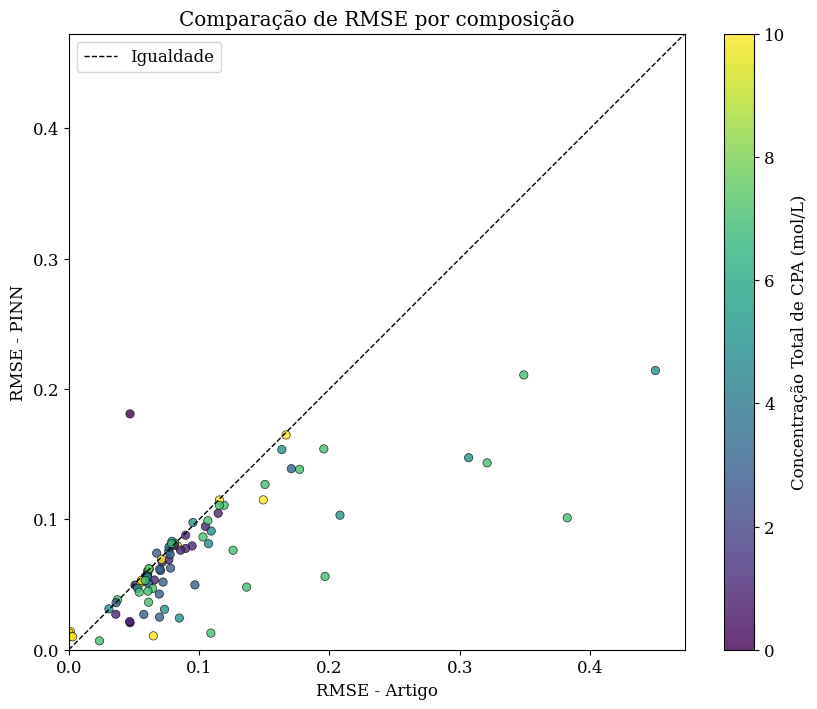

In [ ]:
df_metricas["CPA_Total"] = df_metricas[cpas].sum(axis=1)

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)

scatter = ax.scatter(df_metricas["rmse_artigo"], df_metricas["rmse_pinn"],
                     c=df_metricas["CPA_Total"], cmap="viridis",
                     alpha=0.8, edgecolors="k", linewidths=0.5)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Concentração Total de CPA (mol/L)")

lim_max = max(df_metricas["rmse_artigo"].max(), df_metricas["rmse_pinn"].max()) * 1.05
ax.plot([0, lim_max], [0, lim_max], "k--", lw=1, label="Igualdade")

ax.set_aspect("equal")
ax.set_xlabel("RMSE - Artigo")
ax.set_ylabel("RMSE - PINN")
ax.set_xlim(0, lim_max)
ax.set_ylim(0, lim_max)
ax.legend()
ax.set_title("Comparação de RMSE por composição")

A maior parte dos pontos se concentra abaixo da diagonal, confirmando a vantagem global da PINN. As 16 composições onde o artigo supera a PINN estão distribuídas principalmente na faixa de baixo erro absoluto (canto inferior esquerdo), indicando que nesses casos a diferença entre os modelos é pequena. É possível notar que as composições com maior erro absoluto, mais próximas ao canto superior direito do gráfico, tendem a apresentar maior dispersão em relação à diagonal, sugerindo que os dois modelos diferem mais entre si nas condições de maior toxicidade.

Um possível explicaçõa para a divergência entre os modelos se acentuar nas composições de maior toxicidade, pode ser que quando $k$ é muito elevado, a viabilidade celular cai muito nos primeiros instantes de exposição e os quatro tempos experimentais disponíveis (5, 10, 30 e 60 min) se tornam insuficientes para distinguir entre valores de $k$ muito diferentes. Esse parace ser um limite intrínseco ao conjunto de dados.

### **Curvas de viabilidade**

Para visualizar o comportamento dos dois modelos nas situações experimentais, a figura abaixo apresenta as curvas $N(t)$ geradas pela PINN e pela regressão do artigo para três composições selecionadas, juntamente com os pontos experimentais. 

As composições foram escolhidas para cobrir três diferentes regiões do espaço de desempenho observado: PG 5,0 M, em que os dois modelos produzem curvas próximas entre si e aos dados; FA 5,0 M, em que há uma divergência moderada; e Gly 2,5 M + DMSO 2,5 M, em que há divergência bem considerável entre os modelos; 

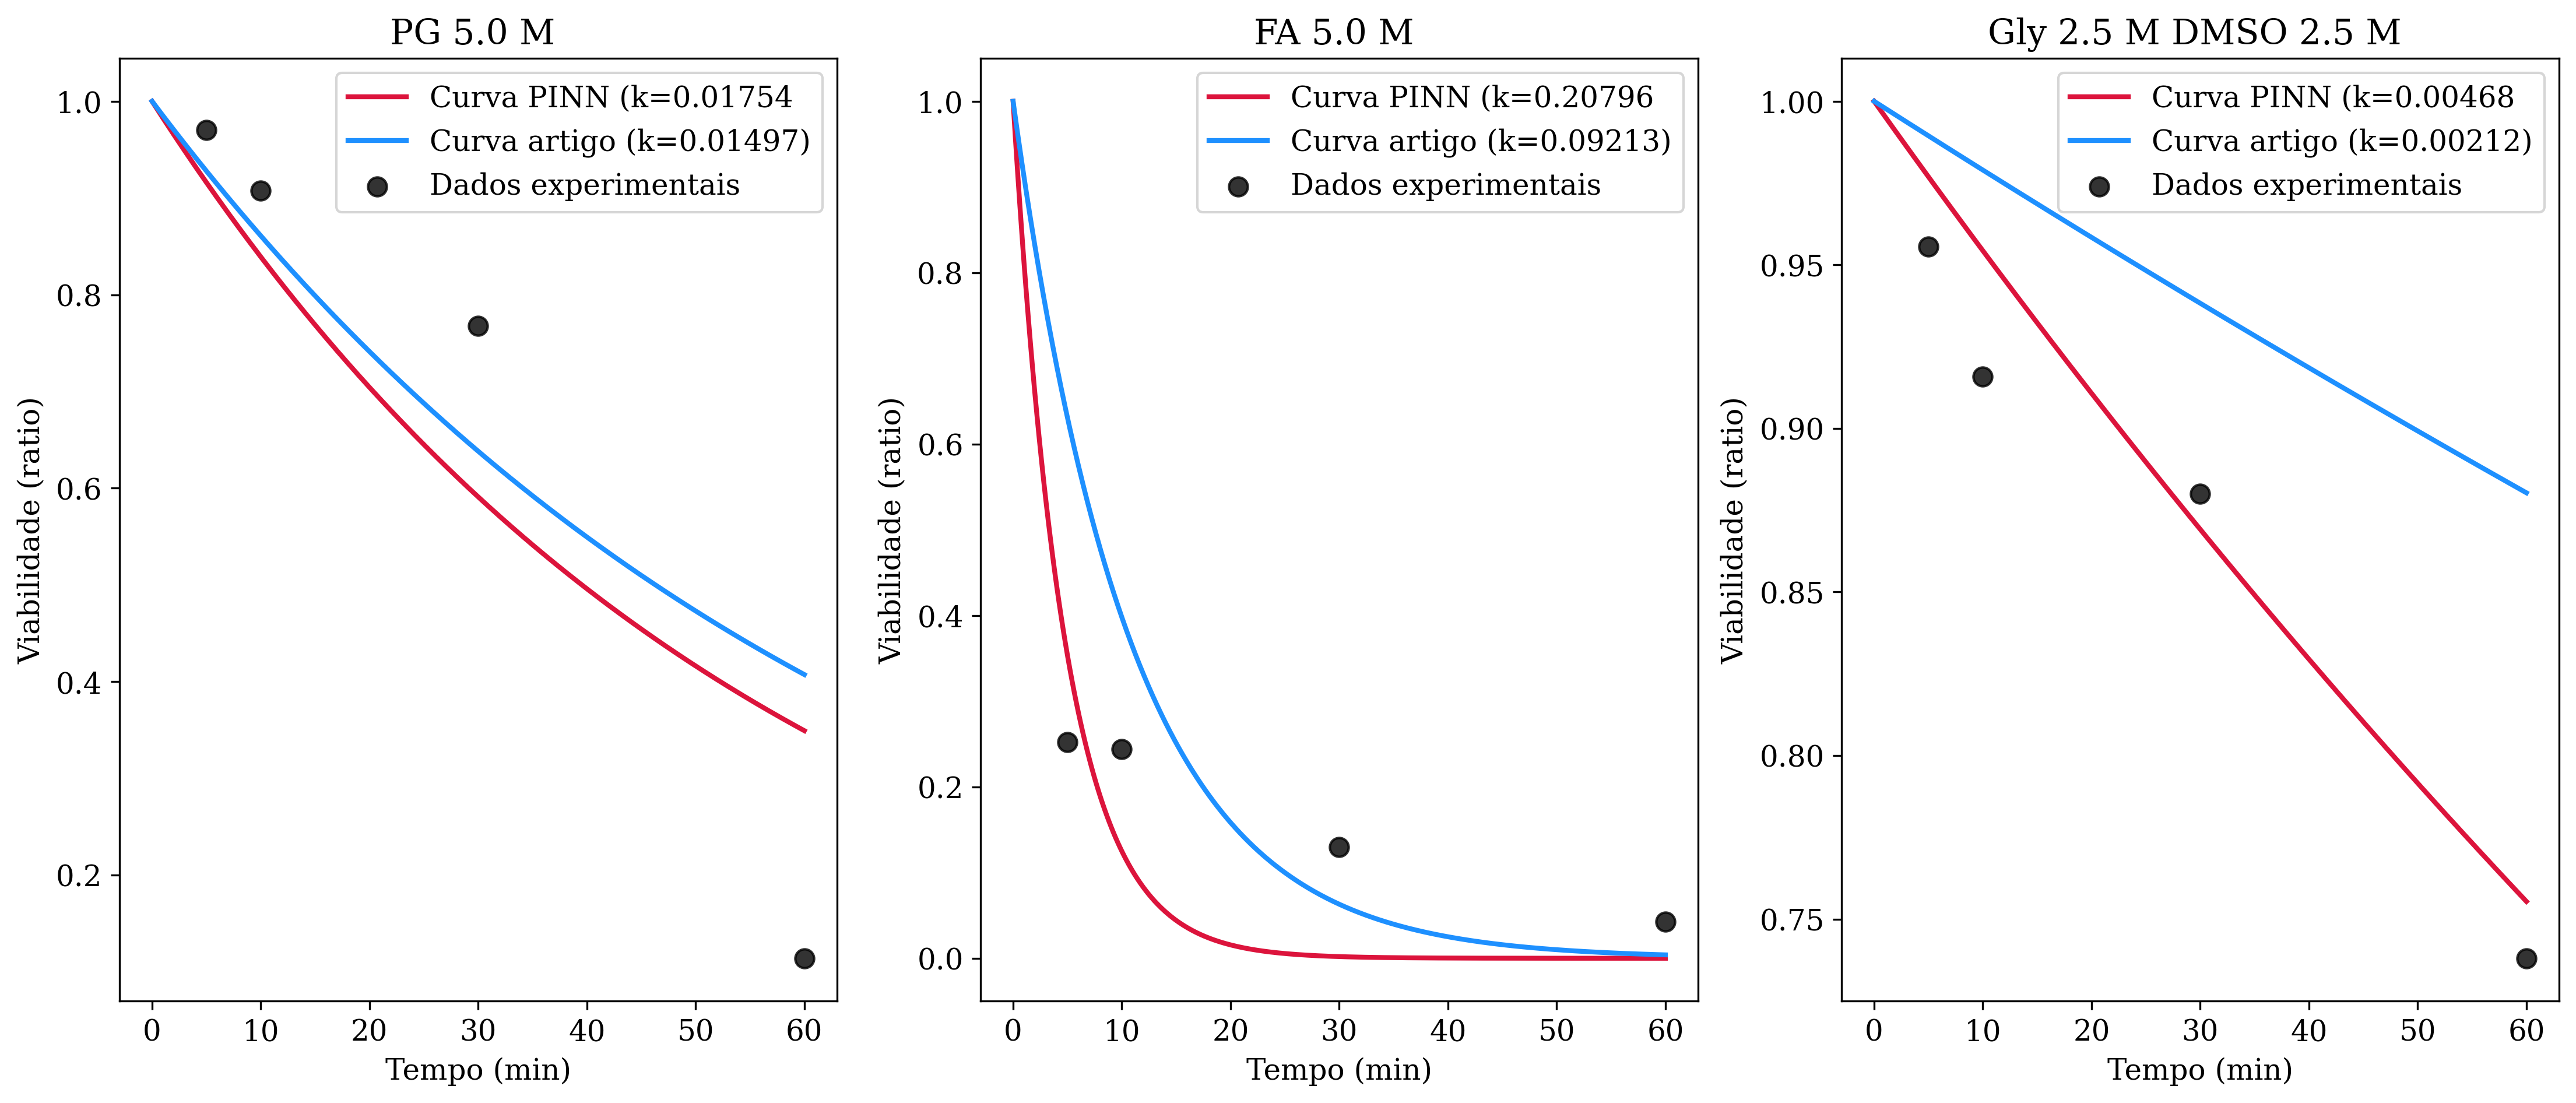

In [104]:
# Gly, DMSO, PG, EG, FA
concentracoes = [
    [0.0, 0.0, 5.0, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 5.0],
    [2.5, 2.5, 0.0, 0.0, 0.0],
]

fig, axs = plt.subplots(1, 3, figsize=(18,7), dpi=300)

for i, concentracao in enumerate(concentracoes):
    df_k_conc = df_k[
        (df_k["Gly (mol/L)"] == concentracao[0]) & 
        (df_k["DMSO (mol/L)"] == concentracao[1]) &
        (df_k["PG (mol/L)"] == concentracao[2]) & 
        (df_k["EG (mol/L)"] == concentracao[3]) & 
        (df_k["FA (mol/L)"] == concentracao[4]) 
    ]

    df_conc_cpas = df_tratado[
        (df_tratado["Gly (mol/L)"] == concentracao[0]) & 
        (df_tratado["DMSO (mol/L)"] == concentracao[1]) &
        (df_tratado["PG (mol/L)"] == concentracao[2]) & 
        (df_tratado["EG (mol/L)"] == concentracao[3]) & 
        (df_tratado["FA (mol/L)"] == concentracao[4]) 
    ]
    
    k_pinn = df_k_conc["k_pinn"].values[0]
    k_artigo = df_k_conc["k_artigo"].values[0]

    tempos_plot = np.linspace(0, 60, 300)
    tempos_exp = df_conc_cpas["Exp Time (min)"].values

    N_exp = df_conc_cpas["Cell Viab (%)"].values

    # N(t) = e^(-k*t)
    N_prev_pinn_plot = np.exp(-k_pinn * tempos_plot)
    N_prev_artigo_plot = np.exp(-k_artigo * tempos_plot)

    N_prev_pinn_exp = np.exp(-k_pinn * tempos_exp)
    N_prev_artigo_exp = np.exp(-k_artigo * tempos_exp)

    titulo = ""
    nomes_dict = {0: "Gly", 1: "DMSO", 2: "PG", 3: "EG", 4: "FA"}
    for j, c in enumerate(concentracao):
        if c != 0.0:
            titulo += f"{nomes_dict[j]} {c} M "

    axs[i].plot(tempos_plot, N_prev_pinn_plot, color="crimson", lw=2, label=f"Curva PINN (k={k_pinn:.5f}")
    axs[i].plot(tempos_plot, N_prev_artigo_plot, color="dodgerblue", lw=2, label=f"Curva artigo (k={k_artigo:.5f})")
    axs[i].scatter(tempos_exp, N_exp, color="black", alpha=0.8, zorder=4, s=60, label="Dados experimentais")

    axs[i].set_title(titulo)
    axs[i].set_xlabel("Tempo (min)")
    axs[i].set_ylabel("Viabilidade (ratio)")
    axs[i].legend()


Nos dois primeiros casos, ambos os modelos acompanham o decaimento observado com erros comparáveis, e a curva da PINN respeita a condição inicial $N(0) = 1$ imposta. No terceiro caso, correspondente a Gly 2,5 M + DMSO 2,5, as curvas divergem de forma mais expressivaem que a curva do artigo não parece acompanhar a velocidade de decaimento dos dados.

A formamida em alta concentração é um dos casos mais representativos do problema de rápido decaimento mencionado anteriormente. A viabilidade celular cai para valores bem baixos no primeiro tempo experimental (5 min), de modo que não é possível visualizar praticamente toda a informação sobre a dinâmica de decaimento está comprimida no intervalo inicial não observado.

## **Conclusão**

Ao fim, esse notebook demonstrou a aplicação de uma *Physics-Informed Neural Network* ao problema inverso de estimação da constante cinética de
toxicidade $k$ em soluções crioprotetoras. A abordagem difere da regressão clássica adotada por Warner et al. (2022) na forma como a estimativa é obtida. De modo que, a PINN incorpora a equação diferencial $dN/dt = -kN$ diretamente na função de perda, tratando a física do sistema como restrição ativa durante o treinamento, e não como hipótese verificada posteriormente.

Os resultados indicam que essa restrição não prejudicou o ajuste aos dados. Mas pelo contrário: avaliando as curvas $N(t) = e^{-kt}$ geradas por
cada modelo em relação aos pontos experimentais brutos, a PINN produziu menor RMSE em 71 das 87 composições avaliadas (81,6%), com RMSE médio
de 0,072 contra 0,097 da regressão do artigo. Nas composições de mais alta toxicidade, acima de 7 mol/L, ambos os modelos apresentam erros maiores e estimativas de $k$ mais divergentes.

### **Perspectivas**

Como extensão deste trabalho, seria interessante explorar o uso da mediana no agrupamento das réplicas, que é mais robusta a outliers do que a média atualmente utilizada. A abordagem pode ainda ser estendida para estimar $k$ como função da composição da solução, integrando o modelo cinético com um modelo preditivo, principalmente para as compisções ternárias, a fim de encontrar aquelas que possuem menor toxicidade.

## **Apêndicie**

### **Funções de perda**

#### **MSE - Erro Quadrático Médio**

$$L_\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} \left(\hat{N}_i - N_i\right)^2$$

O MSE penaliza erros de forma quadrática: um desvio de 0,2 contribui quatro vezes mais do que um desvio de 0,1. Isso torna o MSE sensível a outliers, de forma que um único ponto muito distante da curva pode dominar a perda.

#### **MAE - Erro Absoluto Médio**

$$L_\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} \left|\hat{N}_i - N_i\right|$$

O MAE penaliza todos os erros proporcionalmente à sua magnitude, sem amplificar os grandes. É mais robusto a outliers do que o MSE.

#### **Huber**

$$L_\text{Huber} =
\begin{cases}
\frac{1}{2}\left(\hat{N}_i - N_i\right)^2 & \text{se } |\hat{N}_i - N_i| \leq \delta \\
\delta \left(|\hat{N}_i - N_i| - \frac{\delta}{2}\right) & \text{caso contrário}
\end{cases}$$

A perda de Huber combina as vantagens das duas anteriores. Ela se comporta como MSE para erros pequenos e como MAE para erros grandes. O parâmetro $\delta$ define o limiar entre os dois regimes — no PyTorch, o valor padrão é $\delta = 1$, mas ele também pode ser otimizado.

### **A matemática do weight decay**

Essa técnica de regularização modifica a função de perda original para punir pesos muito grandes. Isso evita o possível *overfitting* e a criação de curvas muito complexas, o que acontece com pesos muito grandes. 

Seja $L_0$ a função de perda original (perda dos dados + perda física + perda da condição inicial), com o *weight decay* a função que a ser otimizada passa a ser:

$$
L = L_0 + \frac{\lambda}{2} \sum _i w_i^2
$$

Onde: 
- $L_0$ é o erro do modelo.
- $\lambda$ é o coeficiente de weight decay.
- $w_i$ são os pesos das camada.

O otimizador busca o mínimo da função, assim, ao derivar a nova função $L$ em relação a um peso $w$, tem-se:

$$
\frac{\partial  L}{\partial w} = \frac{\partial L_0}{\partial w_\text{antigo}} + \lambda w
$$

No algorítmo de gradiente decendente (que é mais simples de explicar), o peos é atualizado muitiplicando esse gradiente pela taxa de aprendizado.

$$
w_\text{novo} = w_\text{antigo} - \eta \left(\frac{\partial L_0}{\partial w_\text{antigo}} + \lambda w_\text{antigo} \right)
$$

$$
w_\text{novo} = w_\text{antigo} (1 - \eta \lambda) - \eta \frac{\partial L_0}{\partial w_\text{antigo}}
$$

Como a taxa de aprendizado $\eta$ e o *weight decay* são, geralmente, valores pequenos o peso atual é ligeiramente reduzido a cada lote que passa. Isso vai se "acumulando" de uma maneira exponencial.

### **A matemática por trás do ``Adam``** [4]

1. **Inicialização:**: é inicializando dois vetores de momento, um para a média do gradiente (primeiro momento - $m$), e outro para a média do quadrado do gradiente (segundo momento - $v$), cada um com o mesmo tamanho do número de parâmetros do modelo.
- $m_0 = 0$
- $v_0 = 0$
- $t = 0$
2. **Cálculo do Gradiente:**
A cada iteração (época) é calculado o gradiente $g_t$, que é a derivada da função de perda (que estamos tentando minimizar), com relação ao parâmetro $\theta _t$ que está sendo atualizado. $$g_t  = \nabla _{\theta} f_t (\theta _{t-1})$$
Em que: 
- $g_t$: gradiente na iteração $t$.
- $\nabla _{\theta}$: o gradiente para o parâmetro $\theta$.
- $f_t (\theta _{t-1})$: a função de perda aplicada aos valores dos parâmetros da iteração anterior.  

3. **Atulização do Primeiro Momento (m):** O primeiro momento é atualizado usando uma média móvel do gradiente. A atualização é a combinação do valor anterior de $m$ e o novo gradiente $g_t$, controlada pelos parâmetros $\beta _1$ e $1 - \beta _1$. Esse processo pode ser visto como uma forma de dar mais peso aos gradientes mais recentes, enquanto ainda mantém uma média dos gradientes anteriores (uma estimativa suave da direção do gradiente). $$m_t = \beta _1 m_{t-1} + (1 - \beta _1) g_t$$ Em que:
- $m_t$: é o vetor do primeiro momento na iteração $t$.
- $\beta _1$: parâmetro de decaimento exponencial para o primeiro momento.
- $m_{t-1}$: é o vetor do primeiro momento na iteração anterior.
- $g_t$: é o vetor do gradiente na iteração $t$.

4. **Atualização do Segundo Momento (v):** O segundo momento é atualizado usando uma média móvel do quadrado do gradiente, como uma variância (imprevisibilidade) dos gradientes. A atualização é a combinação do valor anterior de $v$ e o novo gradiente $g_t$, controlada pelos parâmetros $\beta _2$ e $1 - \beta _2$. $$v_t = \beta _2 v_{t-1} + (1 - \beta _2) g_t^2$$
Em que: 
- $v_t$: é o vetor do segundo momento na iteração $t$.
- $\beta _2$: parâmetro de decaimento exponencial para o segundo momento.
- $v_{t-1}$: é o vetor do segundo momento na iteração anterior.
- $g_t^2$: é o vetor do quadrado do gradiente na iteração $t$.

5. **Correção de Viés:** Devido à inicialização dos momentos com zero, os primeiros momentos tendem a ser subestimados, especialmente nas primeiras iterações. Para corrigir esse viés, são aplicadas as seguintes correções: $$\hat{m}_t = \frac{m_t}{1 - \beta _1^t}$$ $$\hat{v}_t = \frac{v_t}{1 - \beta _2^t}$$ Em que:
- $\hat{m}_t$: é o vetor do primeiro momento corrigido na iteração $t$.
- $\hat{v}_t$: é o vetor do segundo momento corrigido na iteração $t$.
- $\beta _1^t$: é o parâmetro de decaimento exponencial para o primeiro momento na iteração $t$.
- $\beta _2^t$: é o parâmetro de decaimento exponencial para o segundo momento na iteração $t$.

6. **Atualização dos Parâmetros:** Finalmente, os parâmetros do modelo são atualizados usando os momentos corrigidos e a taxa de aprendizado $\alpha$: $$\theta _{t+1} = \theta _{t} - \alpha \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$$ Em que:
- $\theta _{t+1}$: é o vetor de parâmetros atualizado para a próxima iteração.
- $\theta _{t}$: é o vetor de parâmetros na iteração atual.
- $\alpha$: é a taxa de aprendizado, que controla o tamanho do passo de atualização.
- $\hat{m}_t$: é o vetor do primeiro momento corrigido na iteração $t$.
- $\hat{v}_t$: é o vetor do segundo momento corrigido na iteração $t$.
- $\epsilon$: é um pequeno valor adicionado para evitar divisão por zero.

## **Referências**

[1] Raissi, M., Perdikaris, P., & Karniadakis, G. E. (2019). Physics-informed neural networks: A deep learning framework for solving forward and inverse problems involving nonlinear partial differential equations. Journal of Computational Physics, 378, 686–707.

[2] Warner, R. M., et al. (2022). Rapid Quantification of Cryoprotectant Permeability via Numerical Optimization of Differential Scanning Calorimetry Thermograms. Cryobiology. DOI: 10.1016.

[3] CARVALHO, João Cláudio Nunes. O que é uma Physics-Informed Neural Network (PINN)? Medium, 9 ago. 2025. Disponível em: https://joaoclaudionc.medium.com/o-que-%C3%A9-uma-physics-informed-neural-network-pinn-3d0d466693f9. Acesso em: 11 maio. 2026.

[4] PRADHAN, R. The Math Behind Adam Optimizer. Towards Data Science, 2018. Disponível em: https://towardsdatascience.com/the-math-behind-adam-optimizer-c41407efe59b/. Acesso em: 11 maio. 2026.

[5] MULTILAYER perceptron. In: WIKIPEDIA: the free encyclopedia. [S. l.]: Wikimedia Foundation, 2024. Disponível em: https://en.wikipedia.org/wiki/Multilayer_perceptron. Acesso em: 11 maio. 2026.

[6] CASSAR, Daniel Roberto. Multilayer Perceptron em Python puro. [Jupyter Notebook], Ilum – Escola de Ciência, Campinas, 2026.

[7] CASSAR, Daniel Roberto. Construindo e treinando redes neurais com PyTorch e Lightning. [Jupyter Notebook], Ilum – Escola de Ciência, Campinas, 2026.
k.

[8] PYTORCH. MSELoss. PyTorch 2.11 Documentation, [s.d.]. Disponível em: https://docs.pytorch.org/docs/2.11/generated/torch.nn.MSELoss.html. Acesso em: 11 maio. 2026.

[9] PYTORCH. L1Loss. PyTorch 2.11 Documentation, [s.d.]. Disponível em: https://docs.pytorch.org/docs/2.11/generated/torch.nn.L1Loss.html. Acesso em: 11 maio. 2026.

[10] PYTORCH. HuberLoss. PyTorch 2.12 Documentation, [s.d.]. Disponível em: https://docs.pytorch.org/docs/2.12/generated/torch.nn.HuberLoss.html. Acesso em: 11 maio. 2026.

**Autor**: Arthur Brandão do Nascimento